# Preprocessing Pipeline

In [1]:
!pip install pillow
!pip install opencv-python
!pip install torch
!pip install torchvision

In [2]:
import os
import cv2
import numpy as np
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image

In [3]:
DATA_DIR = "datasets/chest_Xray"
IMG_SIZE = 224
BATCH_SIZE = 32

## Load Data

### Contrast improvement

In [4]:
def apply_clahe(img):
    img = np.array(img)

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # Convert back to 3 channels
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img)

In [5]:
class CLAHETransform:
    def __call__(self, img):
        return apply_clahe(img)

### Image noise reduction using Gaussian Blur

In [6]:
def apply_noise_reduction(img, method="gaussian"):
    img_np = np.array(img)
    if method == "gaussian":
        # Gaussian blur: kernel size 3x3, sigma=0 (auto-computed)
        img_np = cv2.GaussianBlur(img_np, (3, 3), sigmaX=0)
    elif method == "median":
        # Median filtering: kernel size 3
        if len(img_np.shape) == 3:
            # Apply channel-wise for RGB
            img_np = np.stack(
                [cv2.medianBlur(img_np[:, :, c], 3) for c in range(img_np.shape[2])],
                axis=2
            )
        else:
            img_np = cv2.medianBlur(img_np, 3)
    return Image.fromarray(img_np)

In [7]:
class NoiseReductionTransform:
    def __init__(self, method="gaussian"):
        self.method = method
 
    def __call__(self, img):
        return apply_noise_reduction(img, method=self.method)

### Greyscale to RGB conversion

In [8]:
class GrayscaleToRGBTransform:
    def __call__(self, img):
        img = np.array(img)
        if len(img.shape) == 2:
            # Single-channel grayscale → duplicate to 3 channels
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = np.repeat(img, 3, axis=2)
        return Image.fromarray(img)

### Data Loading

In [9]:
train_transforms = transforms.Compose([
    GrayscaleToRGBTransform(),
    CLAHETransform(),
    NoiseReductionTransform(method="gaussian"),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485],
                         std=[0.229, 0.229, 0.229])
])

In [10]:
val_test_transforms = transforms.Compose([
    GrayscaleToRGBTransform(),
    CLAHETransform(),
    NoiseReductionTransform(method="gaussian"),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485],
                         std=[0.229, 0.229, 0.229])
])

In [11]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=val_test_transforms
)

In [12]:
my_num_workers = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=my_num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=my_num_workers
)

In [13]:
print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 5216
Validation size: 24
Test size: 625


## Visualize Preprocessing

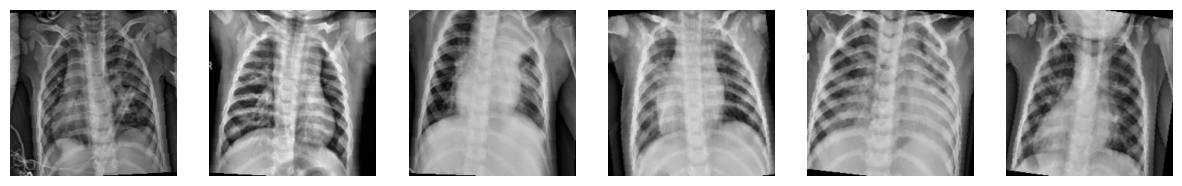

In [14]:
import matplotlib.pyplot as plt

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images[:6]

    fig, axes = plt.subplots(1, 6, figsize=(15,5))
    for i in range(6):
        img = images[i].permute(1,2,0).numpy()
        img = (img * 0.229) + 0.485  # denormalize
        axes[i].imshow(img)
        axes[i].axis('off')

    plt.show()

show_batch(train_loader)